# Actividad 13: Red Neuronal de Clasificación
**Materia:** Análisis Prescriptivo de los Datos  
**Objetivo:** Aplicar el algoritmo de Red Neuronal Artificial para realizar la clasificación de imágenes de números escritos a mano (0 al 9).



#PARTE 1: PREPARACIÓN DE DATOS Y PREPROCESAMIENTO

## 1. Importación de Librerías y Dependencias
En esta sección importamos `tensorflow` para la construcción de la red neuronal y `tensorflow_datasets` para descargar el set de datos oficial de forma directa.


In [ ]:
import tensorflow as tf
import tensorflow_datasets as tfds

## 2. Carga del Conjunto de Datos (MNIST)
Utilizamos el conjunto de datos **MNIST**, un set estándar en Machine Learning que contiene imágenes de dígitos escritos por personas reales.
* El set viene dividido automáticamente en **60,000 imágenes de entrenamiento** y **10,000 imágenes de prueba**.
* Cada imagen tiene una dimensión de **28x28 píxeles** con **1 canal de color** (blanco y negro).


In [ ]:
datos, metadatos = tfds.load("mnist", as_supervised=True, with_info=True)

In [ ]:
metadatos

tfds.core.DatasetInfo(
    name='mnist',
    full_name='mnist/3.0.1',
    description="""
    The MNIST database of handwritten digits.
    """,
    homepage='http://yann.lecun.com/exdb/mnist/',
    data_dir='/root/tensorflow_datasets/mnist/3.0.1',
    file_format=tfrecord,
    download_size=11.06 MiB,
    dataset_size=21.00 MiB,
    features=FeaturesDict({
        'image': Image(shape=(28, 28, 1), dtype=uint8),
        'label': ClassLabel(shape=(), dtype=int64, num_classes=10),
    }),
    supervised_keys=('image', 'label'),
    disable_shuffling=False,
    nondeterministic_order=False,
    splits={
        'test': <SplitInfo num_examples=10000, num_shards=1>,
        'train': <SplitInfo num_examples=60000, num_shards=1>,
    },
    citation="""@article{lecun2010mnist,
      title={MNIST handwritten digit database},
      author={LeCun, Yann and Cortes, Corinna and Burges, CJ},
      journal={ATT Labs [Online]. Available: http://yann.lecun.com/exdb/mnist},
      volume={2},
      year

## 3. Separación de Datos y Extracción de Clases
Separamos el diccionario de datos descargado en las variables correspondientes para entrenamiento (`train`) y pruebas (`test`), además de recuperar el nombre de las 10 clases posibles (números del 0 al 9).


In [ ]:
datos_entrenamiento = datos["train"]
datos_pruebas = datos["test"]

In [ ]:
nombres_clases = metadatos.features["label"].names

## 4. Preprocesamiento: Normalización de los Datos
Originalmente, cada píxel se representa con 1 byte (valores enteros de 0 a 255). Los modelos de redes neuronales convergen de forma más eficiente si los datos de entrada se escalan a números pequeños (entre 0 y 1).
* Convertimos las imágenes a tipo flotante (`float32`).
* Dividimos todos los píxeles entre 255 para lograr el rango esperado [0, 1].
* Aplicamos `.cache()` para almacenar los datos procesados en la memoria RAM y agilizar el entrenamiento en cada época.


In [ ]:
#Normalizacion
#0-255 1 byte
#Transformar 0-255 1-0 (0=0, 255=1, 127=.5)

#Normalizar datos ent y pruebas con una funcion
def normalizar(imagenes, etiquetas):
  imagenes = tf.cast(imagenes, tf.float32)
  imagenes = imagenes/255
  return imagenes, etiquetas

#Normalizar datos
datos_entrenamiento = datos_entrenamiento.map(normalizar)
datos_pruebas = datos_pruebas.map(normalizar)

#Agregar en cache
datos_entrenamiento = datos_entrenamiento.cache()
datos_pruebas = datos_pruebas.cache()

## 5. Exploración Visual del Dataset
Para comprobar que los datos se cargaron y normalizaron correctamente, extraemos muestras utilizando el método `.take()` y las graficamos mediante `matplotlib`. Primero visualizaremos un solo dígito con su barra de escala (comprobando que el rango vaya de 0 a 1) y luego un mosaico de 25 muestras.


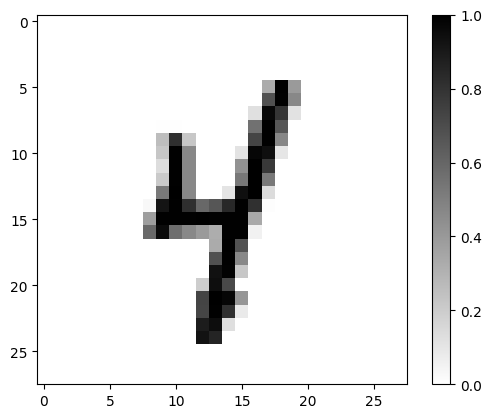

In [ ]:
for imagen, etiqueta in datos_entrenamiento.take(1):
  break

import matplotlib.pyplot as plt

#Mostrarlo en pantalla
plt.figure()
plt.imshow(imagen, cmap=plt.cm.binary)
plt.colorbar()
plt.show()

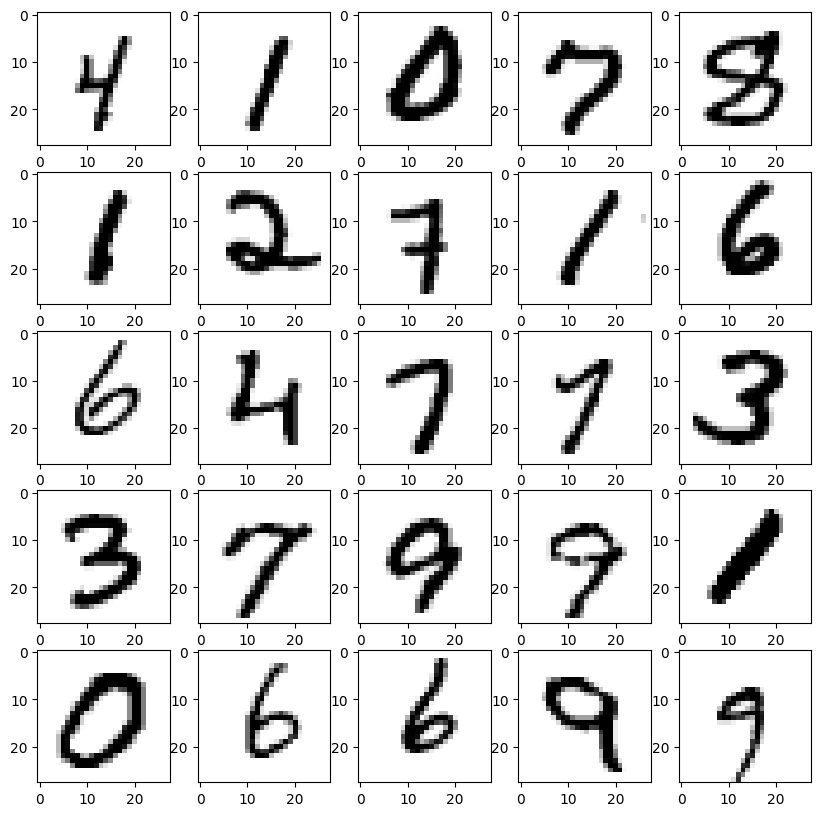

In [ ]:
plt.figure(figsize=(10,10))
for i, (imagen, etiqueta) in enumerate(datos_entrenamiento.take(25)):
  #Mostrarlo en pantalla
  plt.subplot(5, 5, i+1)
  plt.imshow(imagen, cmap=plt.cm.binary)

plt.show()

#PARTE 2: CREACIÓN, ENTRENAMIENTO Y EVALUACIÓN DE LA RED NEURONAL

## 6. Definición de la Arquitectura de la Red Neuronal
Construimos un modelo secuencial (`tf.keras.Sequential`) compuesto por las siguientes capas:
1. **Capa de Aplanado (Flatten):** Toma la matriz cuadrada de la imagen (28x28x1) y la transforma en un vector unidimensional de **784 neuronas de entrada**.
2. **Capas Ocultas (Dense):** Dos capas densas consecutivas de **50 neuronas** cada una con funciones de activación **ReLU**, encargadas de aprender los patrones geométricos de los dígitos.
3. **Capa de Salida (Dense):** Una capa final de **10 neuronas** (una por cada dígito del 0 al 9) combinada con la función de activación **Softmax**. Softmax garantiza que la salida de la red actúe como una distribución de probabilidad, asignando el valor más alto al dígito con mayor certeza.


In [ ]:
modelo = tf.keras.Sequential([
    #784 datos de entrada
    tf.keras.layers.Flatten(input_shape=(28,28,1)), #1 = blanco y negro
    # # # Capa oculta
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    tf.keras.layers.Dense(50, activation=tf.nn.relu),
    # Capa de salida
    tf.keras.layers.Dense(10, activation=tf.nn.softmax)
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


## 7. Compilación del Modelo y Configuración por Lotes (Batching)
* **Compilación:** Usamos el optimizador `adam` y la función de pérdida `SparseCategoricalCrossentropy` idónea para problemas de clasificación multiclase donde las etiquetas son enteros.
* **Lotes:** Definimos un tamaño de lote de 32 (`TAMANO_LOTE`). Los datos de entrenamiento se barajan constantemente (`shuffle`) y se configuran para repetirse de forma infinita durante el ciclo de entrenamiento.


In [ ]:
modelo.compile(
    optimizer="adam",
    loss=tf.keras.losses.SparseCategoricalCrossentropy(),
    metrics=["accuracy"]
)

In [ ]:
TAMANO_LOTE = 32

datos_entrenamiento = datos_entrenamiento.repeat().shuffle(60000).batch(TAMANO_LOTE)
datos_pruebas = datos_pruebas.batch(TAMANO_LOTE)

## 8. Entrenamiento de la Red Neuronal
Procedemos a entrenar el modelo utilizando la función `.fit()`. Configuramos el entrenamiento durante **10 épocas**, calculando matemáticamente los pasos por época necesarios dividiendo el total de imágenes (60,000) entre el tamaño del lote.


In [ ]:
import math
#Entrenar
entrenamiento = modelo.fit(
    datos_entrenamiento, epochs=10,
    steps_per_epoch=math.ceil(60000/TAMANO_LOTE)
)

Epoch 1/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 12s 2ms/step - accuracy: 0.9176 - loss: 0.2854
Epoch 2/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9613 - loss: 0.1293
Epoch 3/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - accuracy: 0.9712 - loss: 0.0936
Epoch 4/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9770 - loss: 0.0749
Epoch 5/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9811 - loss: 0.0601
Epoch 6/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9836 - loss: 0.0530
Epoch 7/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9852 - loss: 0.0456
Epoch 8/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.9879 - loss: 0.0398
Epoch 9/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.9886 - loss: 0.0360
Epoch 10/10
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.9897 - loss: 0.0314


## 9. Evaluación del Modelo y Predicción Visual
Para evaluar la efectividad real de nuestra red neuronal, realizamos predicciones sobre un lote de imágenes de prueba que la red nunca vio durante el entrenamiento.
* Generamos funciones auxiliares para pintar los dígitos junto con sus barras de probabilidad asignadas por Softmax.
* El código resaltará en **azul** las predicciones que sean correctas y en **rojo** aquellas donde la red neuronal haya cometido una equivocación.


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 39ms/step


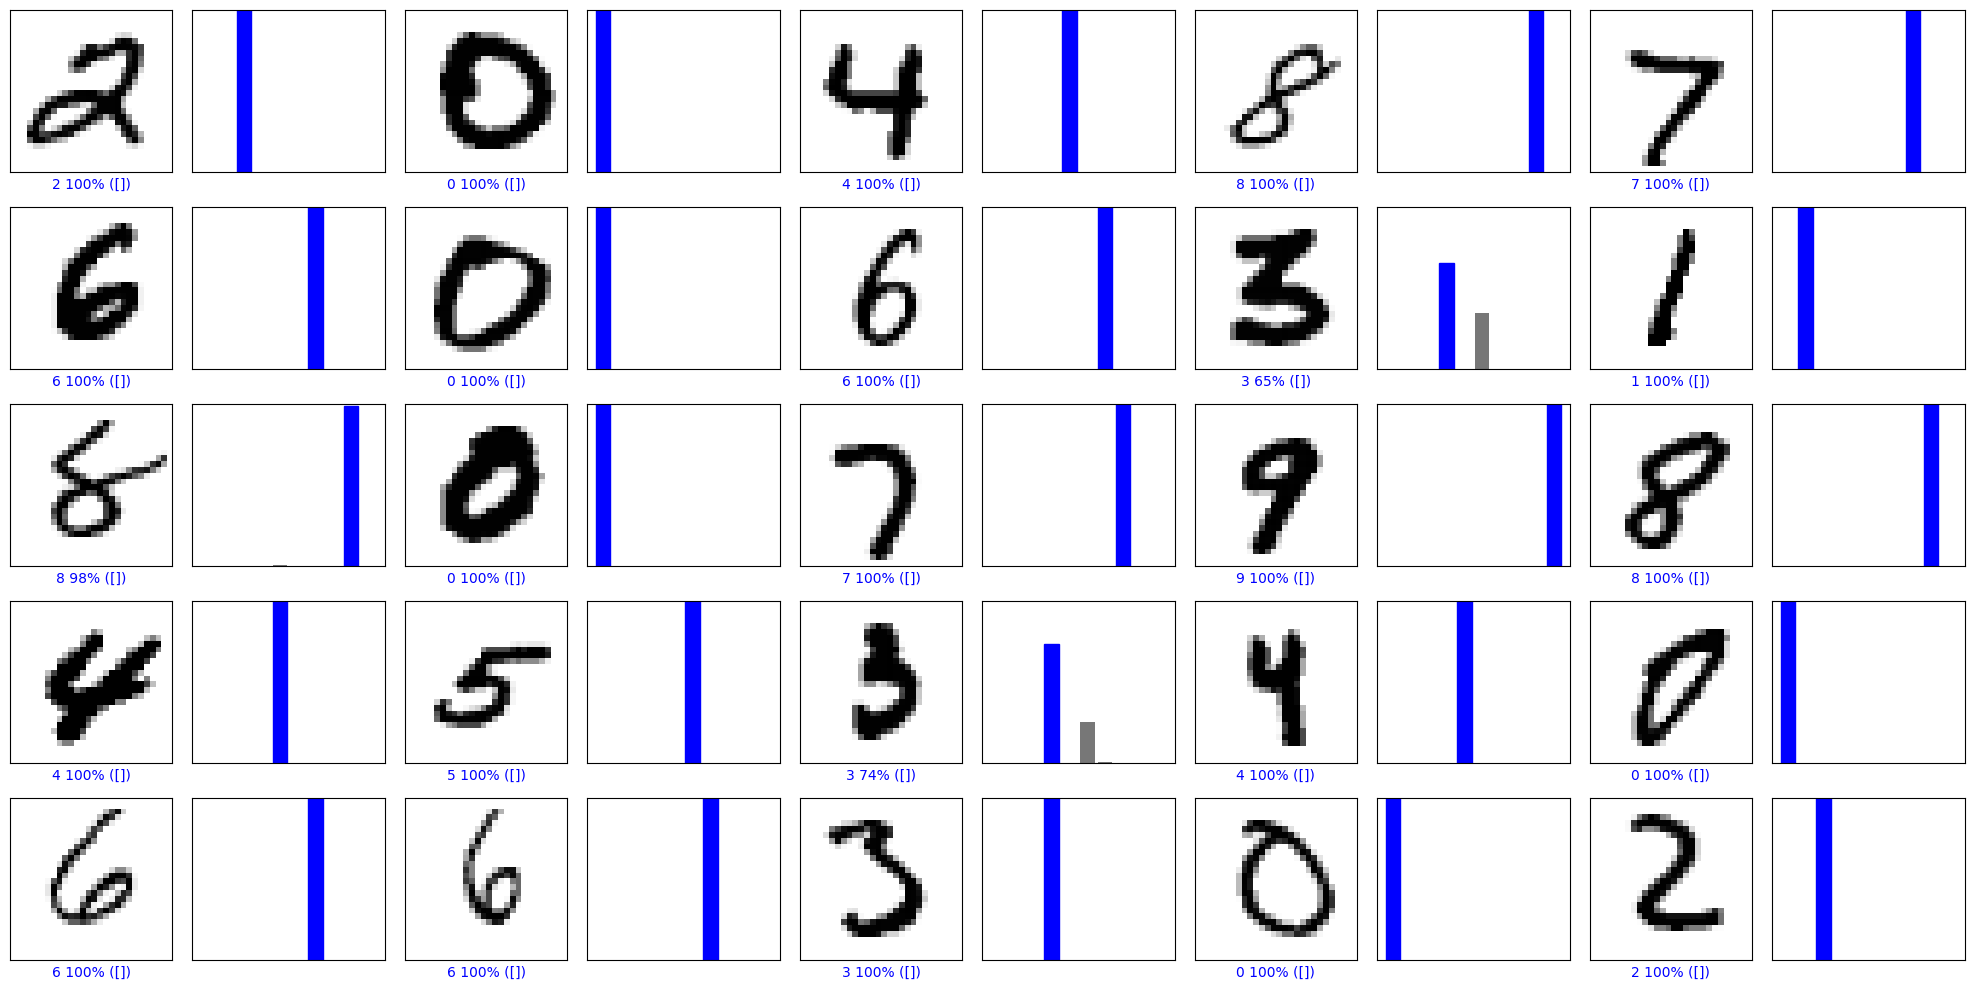

In [ ]:
#Pintar una cuadricula con varias predicciones, y marcar si fue correcta (azul) o incorrecta (roja)
import numpy as np

for imagenes_prueba, etiquetas_prueba in datos_pruebas.take(1):
  imagenes_prueba = imagenes_prueba.numpy()
  etiquetas_prueba = etiquetas_prueba.numpy()
  predicciones = modelo.predict(imagenes_prueba)

def graficar_imagen(i, arr_predicciones, etiquetas_reales, imagenes):
  arr_predicciones, etiqueta_real, img = arr_predicciones[i], etiquetas_reales[i], imagenes[i]
  plt.grid(False)
  plt.xticks([])
  plt.yticks([])

  plt.imshow(img[...,0], cmap=plt.cm.binary)

  etiqueta_prediccion = np.argmax(arr_predicciones)
  if etiqueta_prediccion == etiqueta_real:
    color = 'blue'
  else:
    color = 'red'

  plt.xlabel ("{} {:2.0f}% ([])".format(nombres_clases[etiqueta_prediccion],
                                        100*np.max(arr_predicciones),
                                        nombres_clases[etiqueta_real]),
                                        color = color)

def graficar_valor_arreglo(i, arr_predicciones, etiqueta_real):
    arr_predicciones, etiqueta_real = arr_predicciones[i], etiqueta_real[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    grafica =  plt.bar(range(10), arr_predicciones, color="#777777")
    plt.ylim([0, 1])
    etiqueta_prediccion = np.argmax(arr_predicciones)

    grafica[etiqueta_prediccion].set_color('red')
    grafica[etiqueta_real].set_color('blue')

filas = 5
columnas = 5
num_imagenes = filas*columnas
plt.figure(figsize=(2*2*columnas, 2*filas))

for i in range(num_imagenes):
  plt.subplot(filas, 2*columnas, 2*i+1)
  graficar_imagen(i, predicciones, etiquetas_prueba, imagenes_prueba)
  plt.subplot(filas, 2*columnas, 2*i+2)
  graficar_valor_arreglo(i, predicciones, etiquetas_prueba)

  plt.tight_layout() # Organiza los espacios automáticamente para que no se encimen
plt.show()

## 🔟 Conclusiones de la Actividad

Tras el desarrollo e implementación de la red neuronal artificial para la clasificación del conjunto de datos **MNIST**, se pueden extraer las siguientes conclusiones clave:

* **Efectividad del Preprocesamiento:** La normalización de las imágenes (escalar los píxeles de un rango de 0-255 a un rango de 0-1) resultó fundamental. Este paso redujo la complejidad numérica en la entrada, permitiendo que el optimizador `Adam` convergiera de manera más rápida y eficiente durante las 10 épocas de entrenamiento.
* **Comportamiento de la Arquitectura:** La combinación de una capa de aplanado (`Flatten`) con dos capas ocultas de 50 neuronas (`ReLU`) demostró tener la capacidad suficiente para extraer y aprender los patrones geométricos (curvas, rectas y diagonales) que componen los números escritos a mano.
* **Importancia de Softmax:** La función de activación `Softmax` en la capa de salida cumplió exitosamente su rol probabilístico. Al transformar las salidas en probabilidades competitivas entre las 10 clases, facilitó la identificación del dígito con mayor certeza matemática mediante el uso de la función `argmax`.
* **Análisis Visual de Resultados:** Al evaluar el modelo con datos de prueba nunca antes vistos, la matriz gráfica final demostró visualmente una alta precisión (marcada en azul). Los pocos errores ocurridos (marcados en rojo) se asocian comúnmente a trazos ambiguos o caligrafías difíciles en los números originales, lo cual es un comportamiento esperado en modelos de clasificación estándar.
